Using device: cuda
CUDA cache cleared.


C:\Users\niles\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0, Loss: 9989.23340
Epoch 500, Loss: 6085.40625
Epoch 1000, Loss: 5169.81738
Epoch 1500, Loss: 2634.79297
Epoch 2000, Loss: 1327.41516
Epoch 2500, Loss: 691.43591
Epoch 3000, Loss: 509.19501
Epoch 3500, Loss: 784.68787
Epoch 4000, Loss: 919.59344
Epoch 4500, Loss: 351.60822
Epoch 5000, Loss: 304.83997
Epoch 5500, Loss: 445.46112
Epoch 6000, Loss: 841.70630
Epoch 6500, Loss: 365.05621
Epoch 7000, Loss: 275.27866
Epoch 7500, Loss: 341.81274
Epoch 8000, Loss: 265.09186
Epoch 8500, Loss: 403.07721
Epoch 9000, Loss: 246.31888
Epoch 9500, Loss: 234.44930


C:\Users\niles\AppData\Local\Temp\ipykernel_51616\4196151503.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


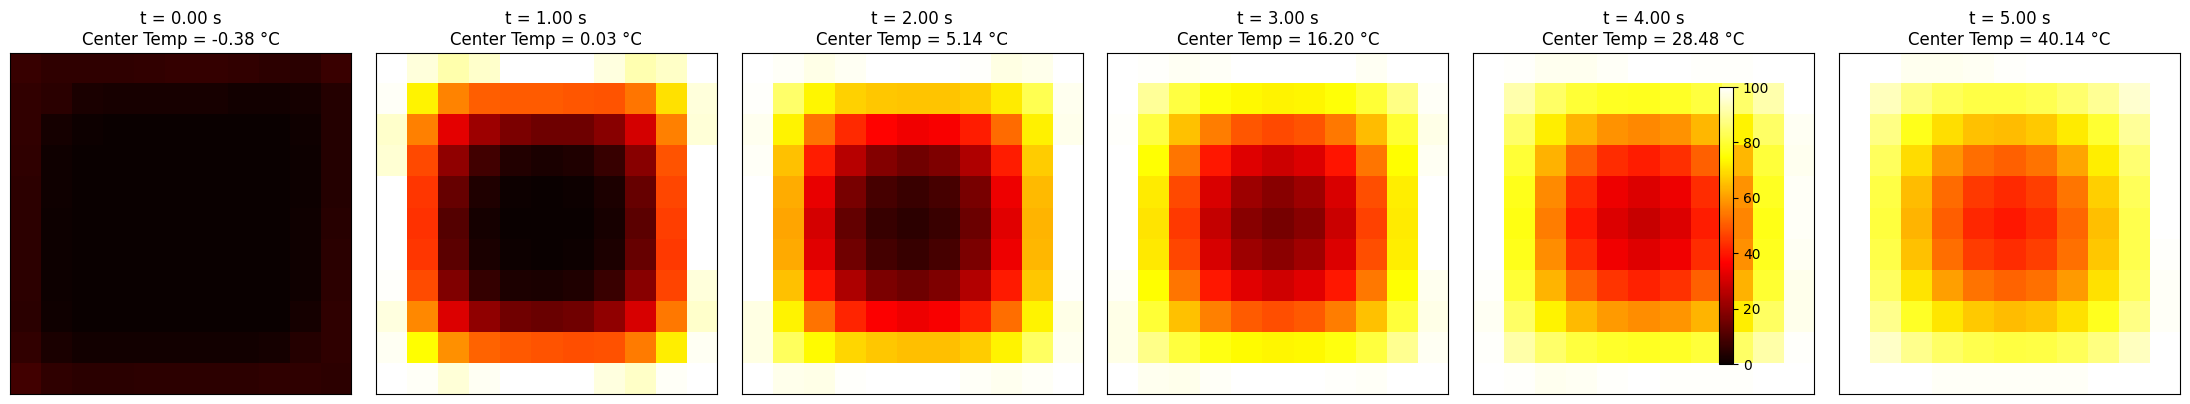

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Define the neural network
class SimpleNN(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=50, output_dim=1, depth=5):
        super(SimpleNN, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(depth):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Define the PINN class
class PINN2DHeat:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")
        self.alpha = 0.01
        self.model = SimpleNN().to(self.device)

        self.dx = 0.1
        self.dt = 0.1
        self.L = 1.0
        self.T = 5.0

        x = torch.arange(0, self.L + self.dx, self.dx)
        y = torch.arange(0, self.L + self.dx, self.dx)
        t = torch.arange(0, self.T + self.dt, self.dt)

        self.x, self.y, self.t = x.to(self.device), y.to(self.device), t.to(self.device)

        # Create boundary points (Dirichlet 100°C)
        Xb, Yb, Tb = [], [], []
        for x_ in x:
            for t_ in t:
                Xb.append([x_, 0.0, t_])
                Xb.append([x_, self.L, t_])
        for y_ in y:
            for t_ in t:
                Yb.append([0.0, y_, t_])
                Yb.append([self.L, y_, t_])
        BC = torch.tensor(Xb + Yb, dtype=torch.float32).to(self.device)
        self.X_bc = BC
        self.y_bc = torch.full((BC.shape[0], 1), 100.0, device=self.device)

        # Create initial condition (u=0 at t=0)
        IC = []
        for x_ in x:
            for y_ in y:
                IC.append([x_, y_, 0.0])
        self.X_ic = torch.tensor(IC, dtype=torch.float32).to(self.device)
        self.y_ic = torch.zeros((len(IC), 1), device=self.device)

        # PDE collocation points
        x_r = torch.rand(10000, 1) * self.L
        y_r = torch.rand(10000, 1) * self.L
        t_r = torch.rand(10000, 1) * self.T
        self.X_r = torch.cat([x_r, y_r, t_r], dim=1).to(self.device)
        self.X_r.requires_grad = True

        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-3)
        self.loss_history = []
        self.criterion = nn.MSELoss()

    def net_pde(self, X):
        u = self.model(X)
        grads = torch.autograd.grad(u, X, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_x, u_y, u_t = grads[:, 0], grads[:, 1], grads[:, 2]

        u_xx = torch.autograd.grad(u_x, X, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 0]
        u_yy = torch.autograd.grad(u_y, X, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:, 1]

        return u_t - self.alpha * (u_xx + u_yy)

    def loss_function(self):
        u_ic = self.model(self.X_ic)
        u_bc = self.model(self.X_bc)
        f_pde = self.net_pde(self.X_r)

        loss_ic = self.criterion(u_ic, self.y_ic)
        loss_bc = self.criterion(u_bc, self.y_bc)
        loss_pde = self.criterion(f_pde, torch.zeros_like(f_pde))

        return loss_ic + loss_bc + loss_pde

    def train(self, epochs=10000):
        # Clear GPU cache at the start of training
        if self.device.type == 'cuda':
            torch.cuda.empty_cache()
            print("CUDA cache cleared.")
            
        for epoch in range(epochs):
            self.optimizer.zero_grad()
            loss = self.loss_function()
            loss.backward()
            self.optimizer.step()
            self.loss_history.append(loss.item())
            if epoch % 500 == 0:
                print(f"Epoch {epoch}, Loss: {loss.item():.5f}")

    def predict(self):
        X, Y, T = torch.meshgrid(self.x, self.y, self.t, indexing='ij')
        points = torch.stack([X.flatten(), Y.flatten(), T.flatten()], dim=1).to(self.device)
        with torch.no_grad():
            u_pred = self.model(points).cpu().numpy().reshape(len(self.x), len(self.y), len(self.t))
        return u_pred

# Train and visualize
pinn = PINN2DHeat()
pinn.train()
u_pred = pinn.predict()

# Plot snapshots
snapshots = [0,10, 20, 30, 40, 50]
x, y, t = pinn.x.cpu().numpy(), pinn.y.cpu().numpy(), pinn.t.cpu().numpy()

fig, axes = plt.subplots(1, len(snapshots), figsize=(22, 4))
for i, idx in enumerate(snapshots):
    ax = axes[i]
    im = ax.imshow(u_pred[:, :, idx], origin='lower', extent=[0, 1, 0, 1],
                   cmap='hot', vmin=0, vmax=100)
    center_temp = u_pred[len(x)//2, len(y)//2, idx]
    ax.set_title(f't = {t[idx]:.2f} s\nCenter Temp = {center_temp:.2f} °C')
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9)
plt.tight_layout()
plt.show()

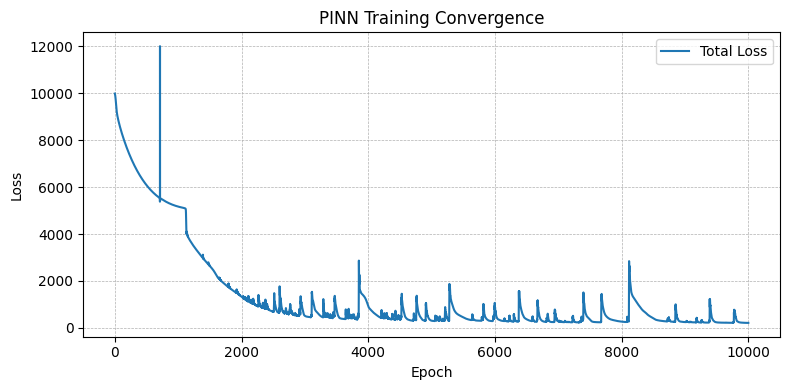

In [3]:
# Plot convergence of total loss
plt.figure(figsize=(8, 4))
plt.plot(pinn.loss_history, label='Total Loss')
#plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PINN Training Convergence')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()